# Reward Analysis Visualization

Visualize and compare reward curves across different training runs.

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

## Load Data

Specify the JSON files you want to compare:

In [7]:
data_folder = Path('../sim/data')

# Specify files to compare
files = [
    'MiniGrid-Empty-5x5-v0_dqn_cp_rank4_seed42.json',
    'MiniGrid-Empty-5x5-v0_dqn_standard_rank4_seed42.json',
]

# Load data
runs = {}
for file in files:
    filepath = data_folder / file
    if filepath.exists():
        with open(filepath, 'r') as f:
            data = json.load(f)
            runs[file.replace('.json', '')] = data
    else:
        print(f"File not found: {filepath}")

print(f"Loaded {len(runs)} runs")
for name in runs:
    print(f"  - {name}: {len(runs[name]['rewards'])} episodes")

Loaded 2 runs
  - MiniGrid-Empty-5x5-v0_dqn_cp_rank4_seed42: 100 episodes
  - MiniGrid-Empty-5x5-v0_dqn_standard_rank4_seed42: 100 episodes


## Plot Reward Curves

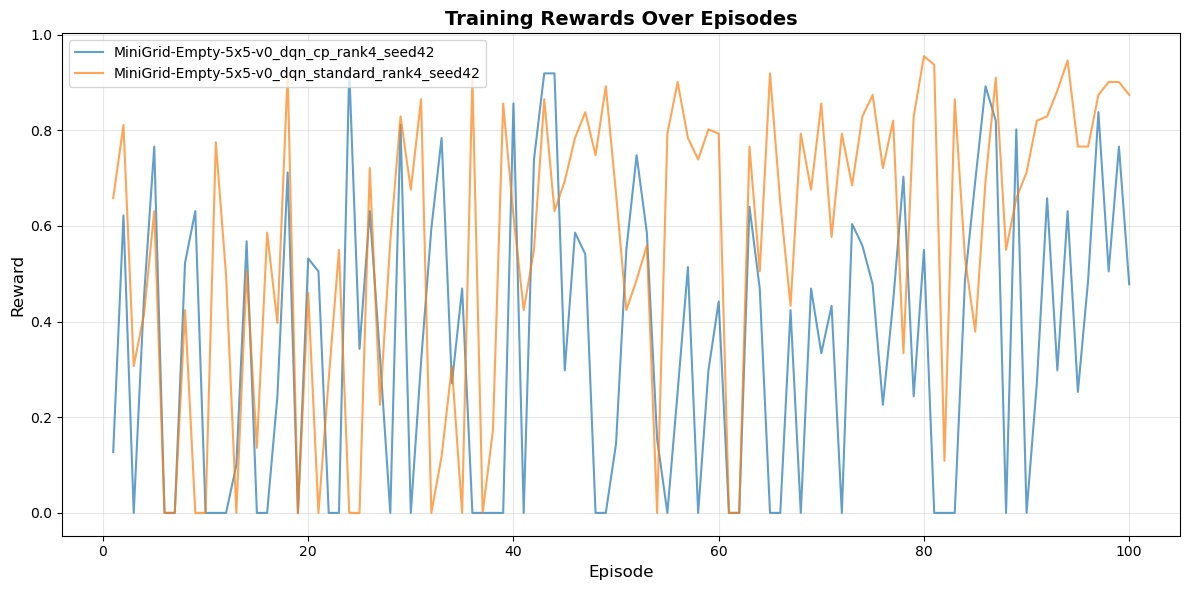

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

for name, data in runs.items():
    episodes = data['episodes']
    rewards = data['rewards']
    ax.plot(episodes, rewards, label=name, alpha=0.7, linewidth=1.5)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Reward', fontsize=12)
ax.set_title('Training Rewards Over Episodes', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Smoothed Reward Curves

Apply moving average to reduce noise:

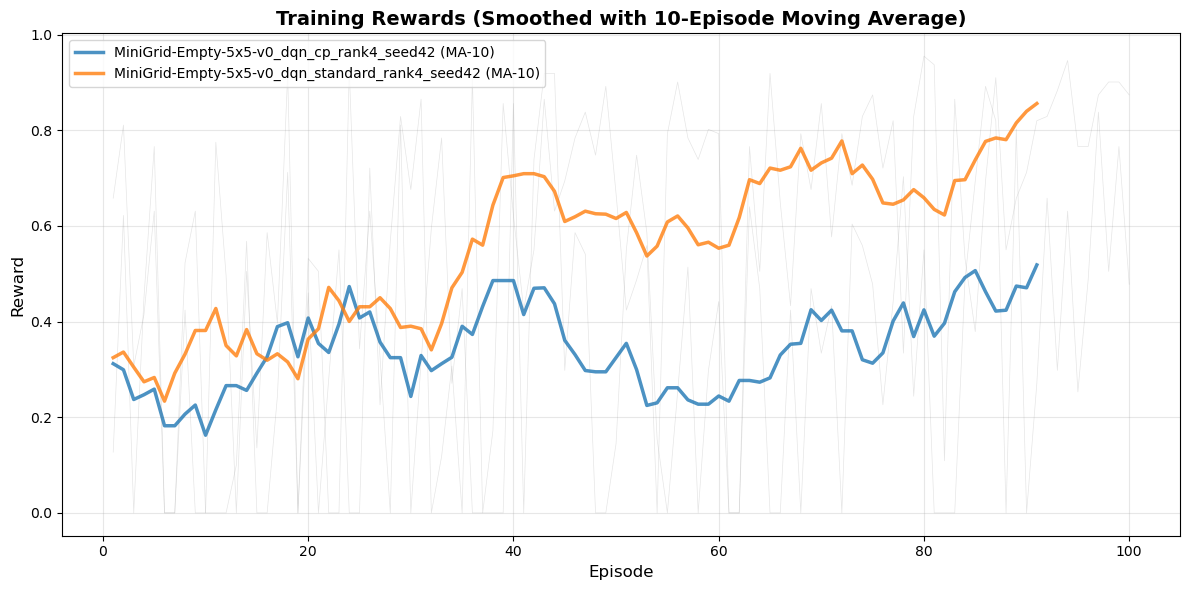

In [9]:
def moving_average(data, window=10):
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(12, 6))

window_size = 10  # Adjust as needed

for name, data in runs.items():
    episodes = data['episodes']
    rewards = data['rewards']
    
    # Plot raw data with low alpha
    ax.plot(episodes, rewards, alpha=0.2, linewidth=0.5, color='gray')
    
    # Plot smoothed curve
    smoothed = moving_average(rewards, window=window_size)
    ax.plot(episodes[:len(smoothed)], smoothed, label=f'{name} (MA-{window_size})', 
            linewidth=2.5, alpha=0.8)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Reward', fontsize=12)
ax.set_title(f'Training Rewards (Smoothed with {window_size}-Episode Moving Average)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Statistics Comparison

In [10]:
stats = []
for name, data in runs.items():
    rewards = data['rewards']
    stats.append({
        'Run': name,
        'Mean Reward': np.mean(rewards),
        'Max Reward': np.max(rewards),
        'Min Reward': np.min(rewards),
        'Std Dev': np.std(rewards),
        'Final Reward': rewards[-1],
        'Episodes': len(rewards)
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

                                            Run  Mean Reward  Max Reward  Min Reward  Std Dev  Final Reward  Episodes
      MiniGrid-Empty-5x5-v0_dqn_cp_rank4_seed42      0.35257       0.928         0.0 0.302705         0.478       100
MiniGrid-Empty-5x5-v0_dqn_standard_rank4_seed42      0.56515       0.955         0.0 0.310327         0.874       100


## Distribution Comparison

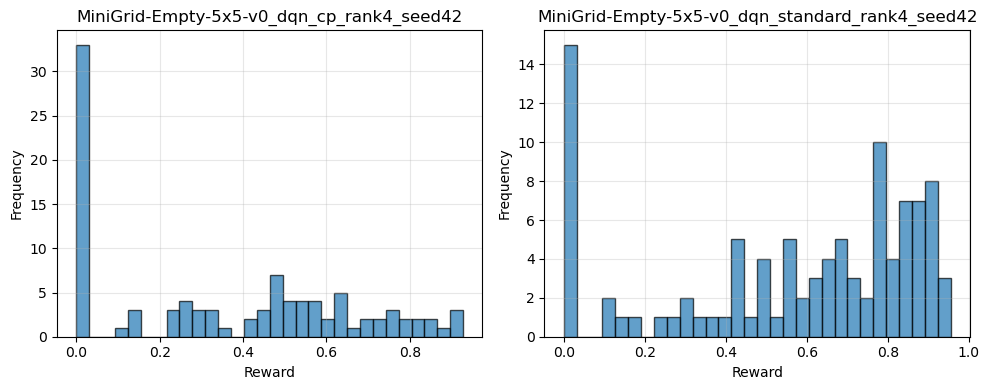

In [11]:
fig, axes = plt.subplots(1, len(runs), figsize=(5*len(runs), 4))

if len(runs) == 1:
    axes = [axes]

for ax, (name, data) in zip(axes, runs.items()):
    rewards = data['rewards']
    ax.hist(rewards, bins=30, alpha=0.7, edgecolor='black')
    ax.set_title(name)
    ax.set_xlabel('Reward')
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()